<a href="https://colab.research.google.com/github/pateld07/undergrad_ml_assignments/blob/main/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

The linear regression model achieved a training MSE of approximately 1.25×10^−30, which is effectively zero.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

The 5-fold cross-validated MSE of the linear regression model is approximately 0.0408, which is much larger than the near-zero training MSE. This large gap indicates that the model is overfitting. Because there are far more predictors than observations, the model has very low bias on the training data but very high variance, meaning it does not generalize well to new data.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

The cross-validated LASSO selected 67 genes and discarded 7062 genes from the model.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

The cross-validated MSE is minimized at approximately
𝛼=0.00287. For large values of α, the penalty is strong and shrinks most coefficients toward zero, leading to underfitting. For very small values of 𝛼, the penalty becomes weak and the model behaves like ordinary least squares, which can lead to overfitting. The optimal value of 𝛼 balances bias and variance by minimizing the cross-validated MSE.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs almost perfectly on the training set because the number of predictors greatly exceeds the number of observations. In this high-dimensional setting, the model can effectively memorize the training data, resulting in near-zero error. The LASSO introduces a penalty that shrinks coefficients and removes irrelevant predictors, reducing variance and improving performance on new data. As a result, the LASSO provides better overall predictions even though it does not perfectly fit the training data.

7. Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods are well-suited for precision health because these problems typically involve very high-dimensional data, such as thousands of gene expression measurements, with relatively small sample sizes. Without regularization, models can easily overfit and produce unreliable predictions.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

the genes it picks can change if you use a slightly different dataset, so the results may not be stable. Also, if genes are very similar, LASSO might randomly choose one over another, which makes it hard to interpret. Just because a gene helps predict something doesn’t mean it actually causes it, so using it for treatment decisions could be misleading. Finally, if the model isn’t tested on new data, it might not work well in real situations and could lead to bad decisions.

In [2]:
import pandas as pd

df = pd.read_csv("/content/sample_data/golub.csv")
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [7]:
# Make binary target:
# ALLB + ALLT = 0, AML = 1
df["target"] = df["cancer"].map({
    "allB": 0,
    "allT": 0,
    "aml": 1
})

# Check that mapping worked
print(df["cancer"].value_counts())
print(df["target"].value_counts())

# Gene columns start after the metadata columns
gene_cols = df.columns[6:-1]   # everything after metadata, before target
X = df[gene_cols]
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

cancer
allB    38
aml     25
allT     9
Name: count, dtype: int64
target
0    47
1    25
Name: count, dtype: int64
X shape: (72, 7129)
y shape: (72,)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X, y)

yhat_train = lr.predict(X)
residuals = y - yhat_train

train_mse = mean_squared_error(y, yhat_train)
print("Training MSE (Linear Regression):", train_mse)

Training MSE (Linear Regression): 1.2522824482837894e-30


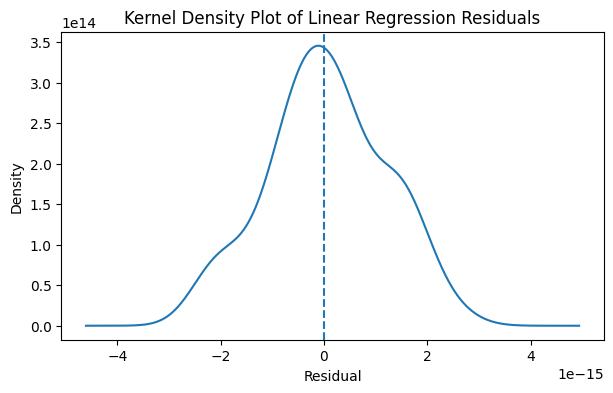

In [9]:
plt.figure(figsize=(7,4))
pd.Series(residuals).plot(kind="kde")
plt.axvline(0, linestyle="--")
plt.title("Kernel Density Plot of Linear Regression Residuals")
plt.xlabel("Residual")
plt.show()

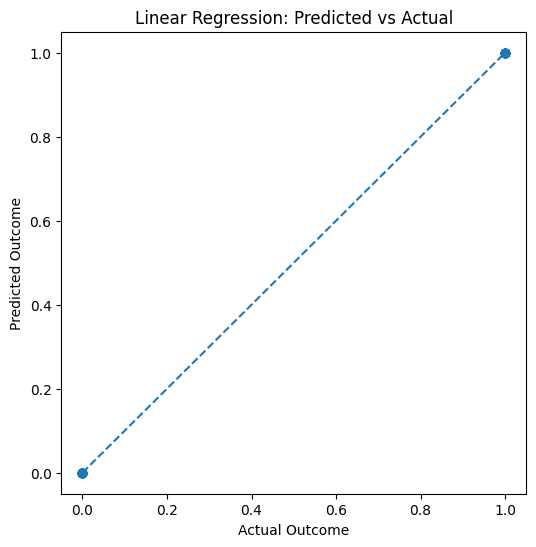

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(y, yhat_train, alpha=0.8)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Actual Outcome")
plt.ylabel("Predicted Outcome")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

In [11]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse_scores = -cross_val_score(
    LinearRegression(),
    X,
    y,
    scoring="neg_mean_squared_error",
    cv=cv
)

print("Fold MSEs:", cv_mse_scores)
print("Mean CV MSE (Linear Regression):", cv_mse_scores.mean())

Fold MSEs: [0.04538415 0.04291022 0.04477968 0.04690803 0.02421453]
Mean CV MSE (Linear Regression): 0.04083932123596972


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        cv=cv,
        random_state=42,
        max_iter=20000,
        alphas=np.logspace(-4, 1, 200)
    ))
])

lasso_pipe.fit(X, y)

best_lasso = lasso_pipe.named_steps["lasso"]
best_alpha = best_lasso.alpha_

print("Best alpha:", best_alpha)

Best alpha: 0.0028660676169482502


In [13]:
lasso_coefs = best_lasso.coef_
selected_mask = lasso_coefs != 0
selected_genes = X.columns[selected_mask]

print("Number of selected genes:", len(selected_genes))
print("Number of discarded genes:", X.shape[1] - len(selected_genes))
print("\nSelected genes:")
print(list(selected_genes))

Number of selected genes: 67
Number of discarded genes: 7062

Selected genes:
['AF000560_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04164_at', 'L13278_at', 'L20941_at', 'M17754_at', 'M19507_at', 'M19645_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27819_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U14588_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U77604_at', 'U82759_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X87838_at', 'X95735_at', 'X96698_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'L15326_s_at', 'U37055_rna1_s_at', 'X07438_s_at', 'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at', 'X12876_s_at', 'U26312_s_at', 'X85116_rna1_s_at', 'L08010_at', 'U84388_at', 'X06

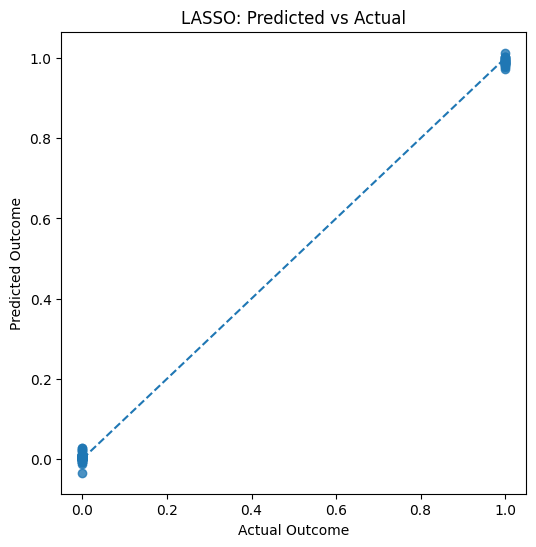

In [14]:
lasso_pred = lasso_pipe.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y, lasso_pred, alpha=0.8)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Actual Outcome")
plt.ylabel("Predicted Outcome")
plt.title("LASSO: Predicted vs Actual")
plt.show()

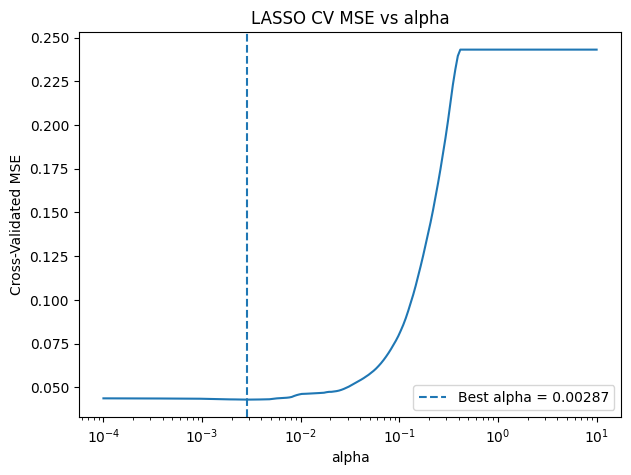

In [15]:
mse_path = best_lasso.mse_path_              # shape: (n_alphas, n_folds)
mean_mse = mse_path.mean(axis=1)
alphas = best_lasso.alphas_

plt.figure(figsize=(7,5))
plt.plot(alphas, mean_mse)
plt.axvline(best_alpha, linestyle="--", label=f"Best alpha = {best_alpha:.5f}")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("LASSO CV MSE vs alpha")
plt.legend()
plt.show()